# Conteggi e percentuali
In questa sezione verranno presentati alcuni dati generali sulla distribuzione delle lingue per famiglie linguistiche e caratteristiche tipologiche.

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
import info
import loader
import stats
import plotter

dataset_path = "../dataset/features.csv"
    
try:
    df = loader.load_data(dataset_path)
except FileNotFoundError as e:
    print(f"Error: dataset file ({dataset_path}) not found")
    sys.exit(1)

## Distribuzione geografica di alcune famiglie linguistiche

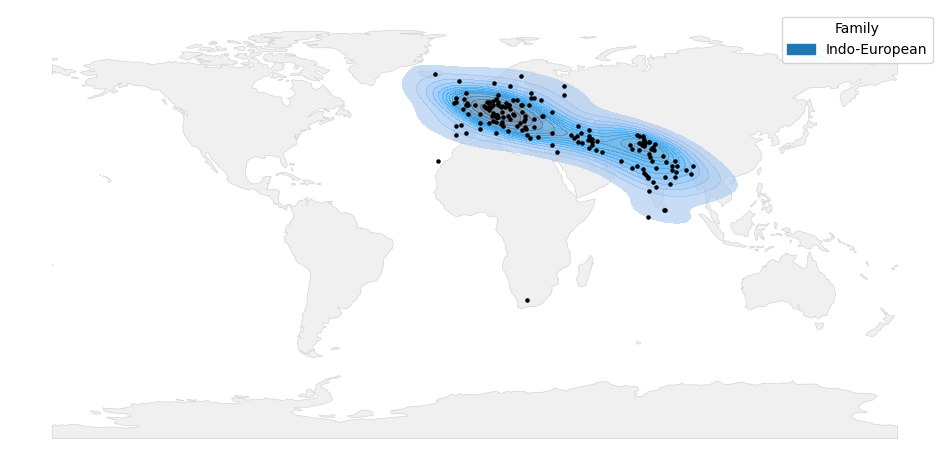

In [2]:
map = stats.map_points(
    df,
    "Family",
    ["Indo-European"]
)

plotter.plot_density_on_map(map, "Family")
plt.show()

## Distribuzione geografica di alcuni valori di parametri

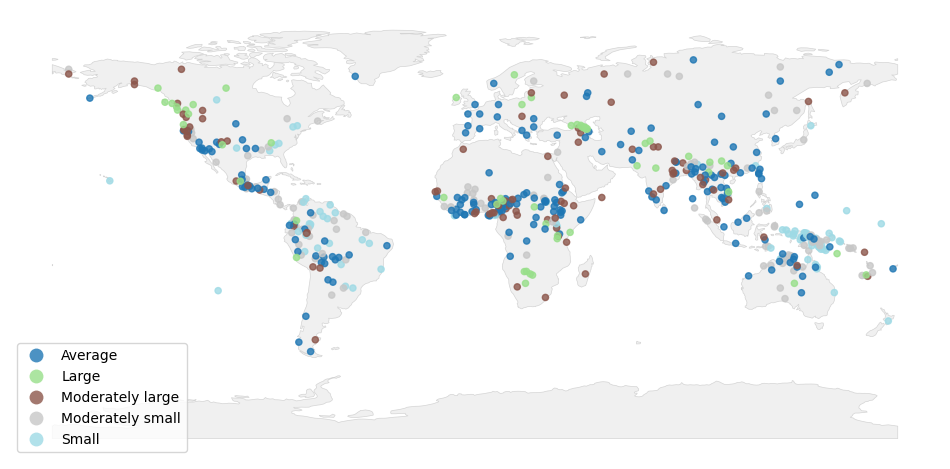

In [3]:
feature_id = "1A"

map = stats.map_points(
    df,
    "Parameter_ID",
    [feature_id]
)

plotter.plot_points_on_map(map, "Code_Name")
plt.show()

## Distribuzione di una feature family-wise

Code_Name     10 or more cases  2 cases  3 cases  4 cases  5 cases  6-7 cases  \
Family                                                                          
Afro-Asiatic                 0        4        1        0        0          2   
Ainu                         0        0        0        0        0          0   
Alacalufan                   0        1        0        0        0          0   
Algic                        0        0        0        0        0          0   
Altaic                       1        0        0        0        0          2   
...                        ...      ...      ...      ...      ...        ...   
Yuchi                        0        0        0        0        0          0   
Yukaghir                     0        0        0        0        0          0   
Zaparoan                     0        0        0        0        0          0   
Zuni                         0        0        0        0        0          0   
other                       

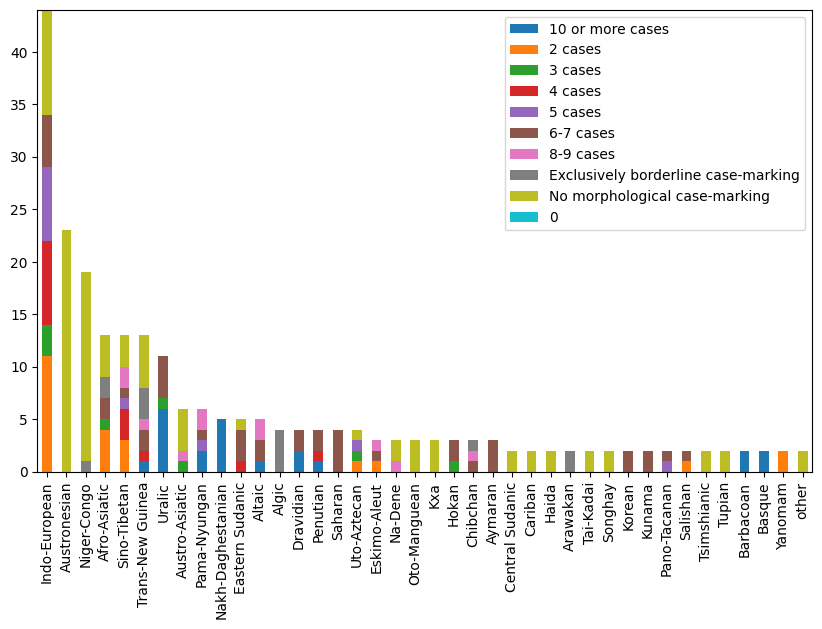

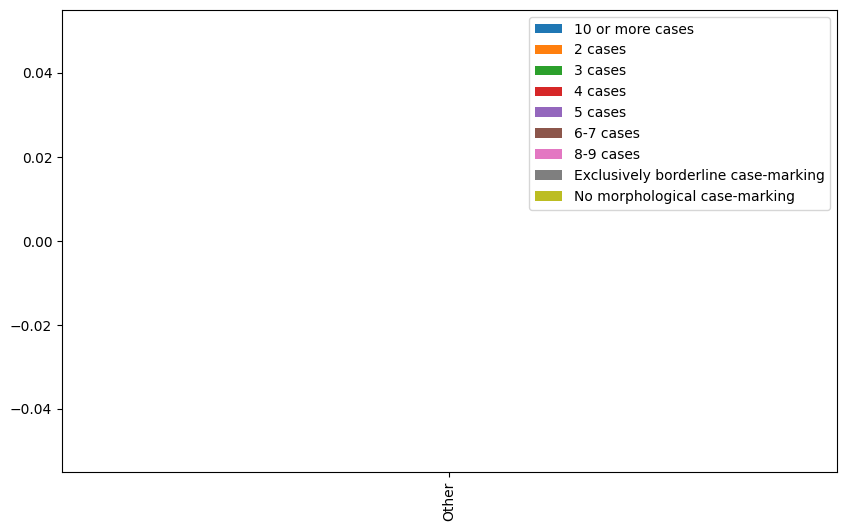

In [ ]:
feature_id = "49A"

qdf = df.copy()
qdf = stats.filter(qdf, "Parameter_ID", [feature_id])
qdf = pd.crosstab(qdf["Family"], qdf["Code_Name"])

n_top = 40
top = (qdf
       .assign(Total=qdf.sum(axis=1))
       .sort_values("Total", ascending=False)
       .drop(columns="Total")
       .head(n_top))

others = qdf.iloc[n_top:]

if not others.empty:
    other_series = pd.Series({"Other": others.sum()})
    languages_by_family = pd.concat([top, other_series])
else:
    languages_by_family = top

languages_by_family_chunks = stats.get_chunks(languages_by_family, 40)

for chunk in languages_by_family_chunks:
    plotter.stacked_bar_plot(chunk)
